In [1]:
!pip install python-docx joblib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 4.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/users/')

Mounted at /users/


In [3]:
import os
import json
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from docx import Document
from datetime import datetime
import joblib

# CONFIGURATION

In [4]:
BASE_SAVE_DIR = "/users/"

DATASET_NAME = "CIC_BCCC_NRC_IoMT_2024"
DATASET_DIR = os.path.join(BASE_SAVE_DIR, DATASET_NAME)

CLIENTS_DIR = os.path.join(DATASET_DIR, "clients_non_iid")
os.makedirs(CLIENTS_DIR, exist_ok=True)

N_CLIENTS = 20
DIRICHLET_ALPHA = 0.3

print("DATASET_DIR:", DATASET_DIR)
print("CLIENTS_DIR:", CLIENTS_DIR)
print("N_CLIENTS:", N_CLIENTS)
print("DIRICHLET_ALPHA:", DIRICHLET_ALPHA)

DATASET_DIR: /users/
CLIENTS_DIR: /users/
N_CLIENTS: 20
DIRICHLET_ALPHA: 0.3


# LOAD TRAIN LATENT FEATURES & LABELS

In [5]:
train_latent_path = os.path.join(DATASET_DIR, "train_latent.npy")
y_train_path      = os.path.join(DATASET_DIR, "y_train.npy")
label_encoder_path = os.path.join(DATASET_DIR, "label_encoder.pkl")

assert os.path.exists(train_latent_path), f"Missing: {train_latent_path}"
assert os.path.exists(y_train_path), f"Missing: {y_train_path}"
assert os.path.exists(label_encoder_path), f"Missing: {label_encoder_path}"

X_train = np.load(train_latent_path)
y_train = np.load(y_train_path)

label_encoder = joblib.load(label_encoder_path)
class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Total classes:", num_classes)
print("Class names:", class_names)

X_train shape: (2369719, 64)
y_train shape: (2369719,)
Total classes: 15
Class names: ['Benign Traffic', 'DDoS ICMP Flood', 'DDoS UDP Flood', 'DoS ICMP Flood', 'DoS TCP Flood', 'DoS UDP Flood', 'MITM ARP Spoofing', 'MQTT DDoS Publish Flood', 'MQTT DoS Connect Flood', 'MQTT DoS Publish Flood', 'MQTT Malformed', 'Recon OS Scan', 'Recon Ping Sweep', 'Recon Port Scan', 'Recon Vulnerability Scan']


# GLOBAL CLASS DISTRIBUTION

Global Class Distribution:
0 - Benign Traffic : 22834
1 - DDoS ICMP Flood : 1786
2 - DDoS UDP Flood : 1803
3 - DoS ICMP Flood : 1475
4 - DoS TCP Flood : 1474841
5 - DoS UDP Flood : 2181
6 - MITM ARP Spoofing : 737
7 - MQTT DDoS Publish Flood : 289739
8 - MQTT DoS Connect Flood : 166622
9 - MQTT DoS Publish Flood : 667
10 - MQTT Malformed : 1572
11 - Recon OS Scan : 59722
12 - Recon Ping Sweep : 50
13 - Recon Port Scan : 339865
14 - Recon Vulnerability Scan : 5825


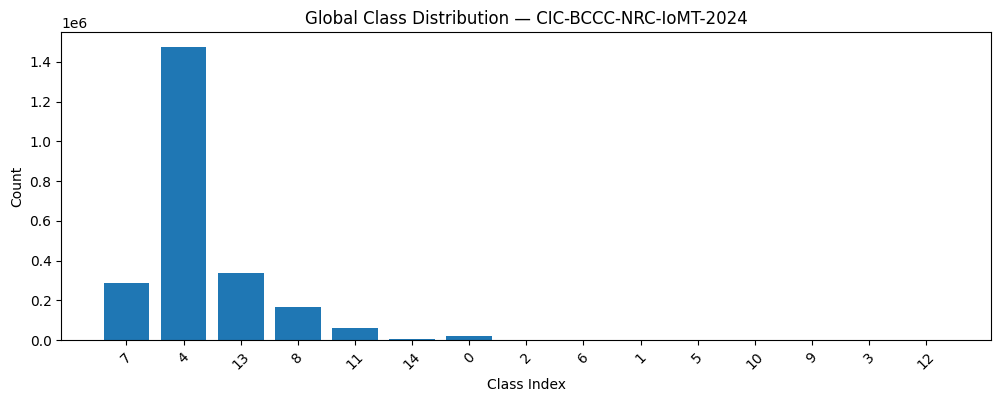

In [6]:
global_counts = Counter(y_train.tolist())

print("Global Class Distribution:")
for cls_idx, cnt in sorted(global_counts.items()):
    print(f"{cls_idx} - {class_names[cls_idx]} : {cnt}")

plt.figure(figsize=(12,4))
plt.bar([str(k) for k in global_counts.keys()], list(global_counts.values()))
plt.title("Global Class Distribution — CIC-BCCC-NRC-IoMT-2024")
plt.xlabel("Class Index")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# DIRICHLET NON-IID PARTITIONING

In [7]:
def dirichlet_partition(y, n_clients, alpha, seed=42):
    np.random.seed(seed)
    random.seed(seed)

    all_indices = np.arange(len(y))
    unique_classes = sorted(list(set(y)))

    class_to_indices = {c: all_indices[y == c] for c in unique_classes}
    for c in class_to_indices:
        np.random.shuffle(class_to_indices[c])

    client_samples = [[] for _ in range(n_clients)]

    for cls, idxs in class_to_indices.items():
        n = len(idxs)
        if n == 0:
            continue

        proportions = np.random.dirichlet([alpha] * n_clients)
        counts = (proportions * n).astype(int)
        diff = n - counts.sum()
        for _ in range(diff):
            counts[np.random.randint(0, n_clients)] += 1

        start = 0
        for client_id in range(n_clients):
            amount = counts[client_id]
            if amount > 0:
                client_samples[client_id].extend(idxs[start:start + amount])
                start += amount

    # shuffle inside client
    for cid in range(n_clients):
        np.random.shuffle(client_samples[cid])
        client_samples[cid] = np.array(client_samples[cid])

    return client_samples

# Build Strong Non-IID Clients

In [8]:
client_indices = dirichlet_partition(
    y_train,
    n_clients=N_CLIENTS,
    alpha=DIRICHLET_ALPHA,
    seed=42
)

total = sum(len(idx) for idx in client_indices)
print("Total assigned samples:", total)
print("Original train samples:", len(y_train))
assert total == len(y_train), "Error: sample mismatch!"

Total assigned samples: 2369719
Original train samples: 2369719


# Client Distribution Summary

In [9]:
def class_dist(indices):
    c = Counter(y_train[indices].tolist())
    return {int(k): int(v) for k, v in sorted(c.items())}

client_stats = []

for cid, idxs in enumerate(client_indices):
    dist = class_dist(idxs)
    top3 = sorted(dist.items(), key=lambda x: x[1], reverse=True)[:3]
    top3_readable = [f"{cls}({class_names[cls]})={cnt}" for cls, cnt in top3]

    client_stats.append({
        "client_id": cid,
        "num_samples": len(idxs),
        "num_classes": len(dist),
        "class_distribution": dist,
        "top_classes": top3_readable
    })

for s in client_stats:
    print(f"\nClient {s['client_id']}:")
    print("  Samples     :", s["num_samples"])
    print("  #Classes    :", s["num_classes"])
    print("  Top Classes :", ", ".join(s["top_classes"]))


Client 0:
  Samples     : 58524
  #Classes    : 15
  Top Classes : 8(MQTT DoS Connect Flood)=33909, 7(MQTT DDoS Publish Flood)=12207, 11(Recon OS Scan)=9960

Client 1:
  Samples     : 82344
  #Classes    : 14
  Top Classes : 13(Recon Port Scan)=48269, 7(MQTT DDoS Publish Flood)=25128, 8(MQTT DoS Connect Flood)=5655

Client 2:
  Samples     : 43746
  #Classes    : 14
  Top Classes : 4(DoS TCP Flood)=26517, 7(MQTT DDoS Publish Flood)=11637, 8(MQTT DoS Connect Flood)=2452

Client 3:
  Samples     : 117869
  #Classes    : 15
  Top Classes : 7(MQTT DDoS Publish Flood)=47286, 4(DoS TCP Flood)=42123, 13(Recon Port Scan)=24132

Client 4:
  Samples     : 205347
  #Classes    : 15
  Top Classes : 4(DoS TCP Flood)=193957, 13(Recon Port Scan)=7443, 8(MQTT DoS Connect Flood)=2677

Client 5:
  Samples     : 71259
  #Classes    : 14
  Top Classes : 7(MQTT DDoS Publish Flood)=32058, 8(MQTT DoS Connect Flood)=25512, 13(Recon Port Scan)=9167

Client 6:
  Samples     : 252278
  #Classes    : 12
  Top Cl

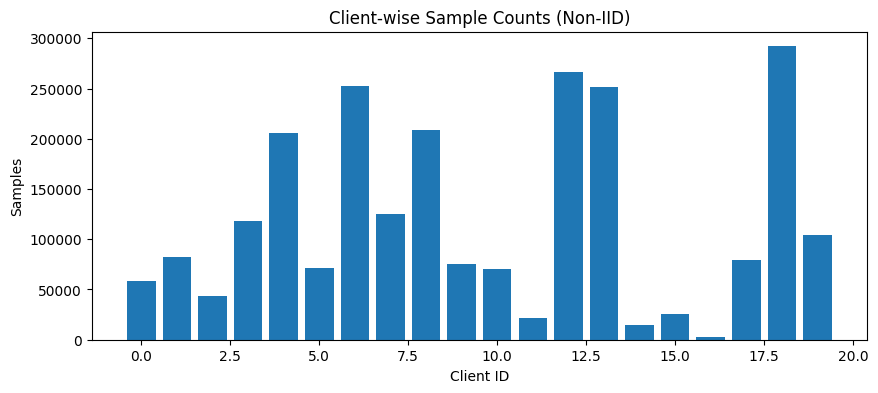

In [10]:
sizes = [s["num_samples"] for s in client_stats]
plt.figure(figsize=(10,4))
plt.bar(range(N_CLIENTS), sizes)
plt.title("Client-wise Sample Counts (Non-IID)")
plt.xlabel("Client ID")
plt.ylabel("Samples")
plt.show()

# Save Client Datasets

In [11]:
for cid, idxs in enumerate(client_indices):
    folder = os.path.join(CLIENTS_DIR, f"client_{cid}")
    os.makedirs(folder, exist_ok=True)

    Xc = X_train[idxs]
    yc = y_train[idxs]

    np.save(os.path.join(folder, "X.npy"), Xc)
    np.save(os.path.join(folder, "y.npy"), yc)

print("✔ Saved client datasets to:", CLIENTS_DIR)

✔ Saved client datasets to: /users/


# Save Metadata JSON

In [12]:
metadata = {
    "dataset_name": DATASET_NAME,
    "generated_at": datetime.now().isoformat(),
    "n_clients": N_CLIENTS,
    "dirichlet_alpha": DIRICHLET_ALPHA,
    "global": {
        "num_samples": len(y_train),
        "num_classes": num_classes,
        "class_index_to_name": {int(i): str(n) for i, n in enumerate(class_names)},
        "class_distribution": {int(k): int(v) for k, v in sorted(global_counts.items())}
    },
    "clients": []
}

for s in client_stats:
    metadata["clients"].append({
        "client_id": s["client_id"],
        "num_samples": s["num_samples"],
        "num_classes": s["num_classes"],
        "class_distribution": s["class_distribution"],
        "top_classes": s["top_classes"]
    })

json_path = os.path.join(CLIENTS_DIR, "clients_metadata.json")
with open(json_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("✔ Metadata saved:", json_path)

✔ Metadata saved: /users/


# DOCX Report

In [13]:

doc = Document()
doc.add_heading(f"Client Partition Summary — {DATASET_NAME}", level=1)

doc.add_paragraph(f"Generated at: {datetime.now()}")
doc.add_paragraph(f"Number of clients: {N_CLIENTS}")
doc.add_paragraph(f"Dirichlet alpha: {DIRICHLET_ALPHA}")
doc.add_paragraph(f"Train samples: {len(y_train)}")

doc.add_heading("Global Class Distribution", level=2)
for cls_idx, cnt in sorted(global_counts.items()):
    doc.add_paragraph(f"{cls_idx} ({class_names[cls_idx]}): {cnt}", style="List Bullet")

doc.add_heading("Client Summary", level=2)
tbl = doc.add_table(rows=1, cols=5)
hdr = tbl.rows[0].cells
hdr[0].text = "Client ID"
hdr[1].text = "#Samples"
hdr[2].text = "#Classes"
hdr[3].text = "Top 3 Classes"
hdr[4].text = "Class Dist (truncated)"

for s in client_stats:
    row = tbl.add_row().cells
    row[0].text = str(s["client_id"])
    row[1].text = str(s["num_samples"])
    row[2].text = str(s["num_classes"])
    row[3].text = ", ".join(s["top_classes"])

    # truncated
    dist = list(s["class_distribution"].items())
    d_str = ", ".join([f"{cls}:{cnt}" for cls, cnt in dist[:4]])
    if len(dist) > 4:
        d_str += " ..."
    row[4].text = d_str

doc_path = os.path.join(CLIENTS_DIR, "clients_metadata_summary.docx")
doc.save(doc_path)

print("✔ DOCX saved:", doc_path)

✔ DOCX saved: /users/
